## 📘 Support Ticket Classification (Using Twitter Dataset)

In [1]:
## Cell 1: Import Libraries

import pandas as pd
import numpy as np
import re
import nltk

nltk.download('stopwords')
from nltk.corpus import stopwords

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/harsha/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [2]:
## Cell 2: Load Dataset
df = pd.read_csv("sample.csv")   # your uploaded file name
df.head()

,tweet_id,author_id,inbound,created_at,text,response_tweet_id,in_response_to_tweet_id
0,119237,105834,True,Wed Oct 11 06:55:44 +0000 2017,@AppleSupport causing the reply to be disregar...,119236,NaN
1,119238,ChaseSupport,False,Wed Oct 11 13:25:49 +0000 2017,@105835 Your business means a lot to us. Pleas...,NaN,119239.0
2,119239,105835,True,Wed Oct 11 13:00:09 +0000 2017,@76328 I really hope you all change but I'm su...,119238,NaN
3,119240,VirginTrains,False,Tue Oct 10 15:16:08 +0000 2017,@105836 LiveChat is online at the moment - htt...,119241,119242.0
4,119241,105836,True,Tue Oct 10 15:17:21 +0000 2017,@VirginTrains see attached error message. I've...,119243,119240.0


In [3]:
##Cell 3: Basic Info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 93 entries, 0 to 92
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   tweet_id                 93 non-null     int64  
 1   author_id                93 non-null     object 
 2   inbound                  93 non-null     bool   
 3   created_at               93 non-null     object 
 4   text                     93 non-null     object 
 5   response_tweet_id        65 non-null     object 
 6   in_response_to_tweet_id  68 non-null     float64
dtypes: bool(1), float64(1), int64(1), object(4)
memory usage: 4.6+ KB


In [4]:
##Cell 4: Filter Only Customer Messages
df = df[df['inbound'] == True]

In [5]:
##Cell 5: Keep Required Column
df = df[['text']]
df = df.dropna()
df.head()

,text
0,@AppleSupport causing the reply to be disregar...
2,@76328 I really hope you all change but I'm su...
4,@VirginTrains see attached error message. I've...
6,"@VirginTrains yep, I've tried laptop too sever..."
8,@VirginTrains I still haven't heard &amp; the ...


In [6]:
##Cell 6: Create Labels (IMPORTANT)
def label_ticket(text):
    text = text.lower()
    
    if "refund" in text or "payment" in text:
        return "billing"
    elif "not working" in text or "error" in text or "crash" in text:
        return "technical"
    elif "delay" in text or "late" in text:
        return "delivery"
    elif "hack" in text or "account" in text:
        return "security"
    else:
        return "other"

df['category'] = df['text'].apply(label_ticket)
df.head()

,text,category
0,@AppleSupport causing the reply to be disregar...,other
2,@76328 I really hope you all change but I'm su...,other
4,@VirginTrains see attached error message. I've...,technical
6,"@VirginTrains yep, I've tried laptop too sever...",other
8,@VirginTrains I still haven't heard &amp; the ...,other


In [7]:
##Cell 7: Text Cleaning
stop_words = set(stopwords.words('english'))

def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-zA-Z]', ' ', text)
    words = text.split()
    words = [w for w in words if w not in stop_words]
    return " ".join(words)

In [8]:
##Cell 8: Apply Cleaning
df['clean_text'] = df['text'].apply(clean_text)

In [9]:
##Cell 9: Feature Extraction (TF-IDF)
vectorizer = TfidfVectorizer(max_features=5000)

X = vectorizer.fit_transform(df['clean_text'])
y = df['category']

In [10]:
##Cell 10: Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [12]:
##Cell 11: Train Model
model = LogisticRegression(max_iter=200)
model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [13]:
##Cell 12: Prediction
y_pred = model.predict(X_test)

In [14]:
##Cell 13: Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.7

Classification Report:
               precision    recall  f1-score   support

     billing       0.00      0.00      0.00         1
    delivery       0.00      0.00      0.00         2
       other       0.70      1.00      0.82         7

    accuracy                           0.70        10
   macro avg       0.23      0.33      0.27        10
weighted avg       0.49      0.70      0.58        10



/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this beha

In [15]:
##Cell 14: Priority Logic
def get_priority(category):
    if category == "security":
        return "High"
    elif category == "billing":
        return "Medium"
    else:
        return "Low"

In [16]:
##Cell 15: Final Prediction Function
def predict_ticket(text):
    cleaned = clean_text(text)
    vec = vectorizer.transform([cleaned])
    category = model.predict(vec)[0]
    priority = get_priority(category)
    
    return category, priority

# Test
ticket = "My account is hacked and I lost access"

category, priority = predict_ticket(ticket)

print("Ticket:", ticket)
print("Category:", category)
print("Priority:", priority)

Ticket: My account is hacked and I lost access
Category: other
Priority: Low


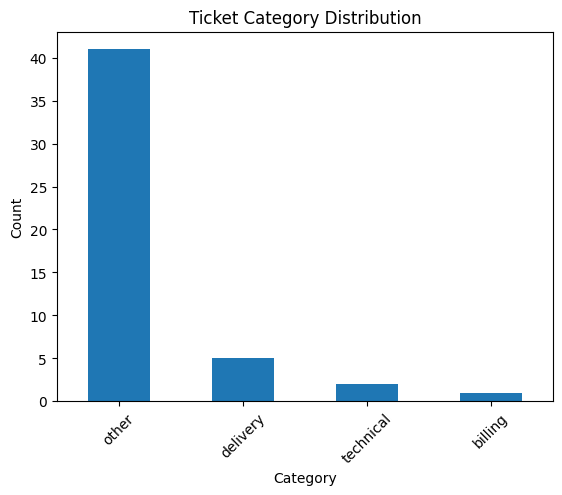

In [17]:
##Cell 16: Category Distribution
import matplotlib.pyplot as plt

df['category'].value_counts().plot(kind='bar')

plt.title("Ticket Category Distribution")
plt.xlabel("Category")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

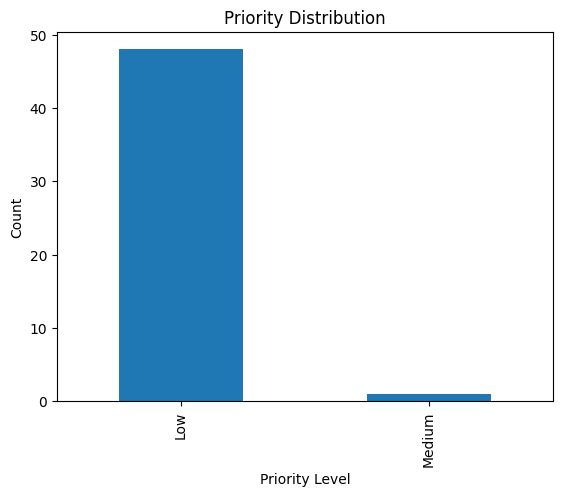

In [18]:
##Cell 17: Priority Distribution
df['priority'] = df['category'].apply(get_priority)

df['priority'].value_counts().plot(kind='bar')

plt.title("Priority Distribution")
plt.xlabel("Priority Level")
plt.ylabel("Count")
plt.show()

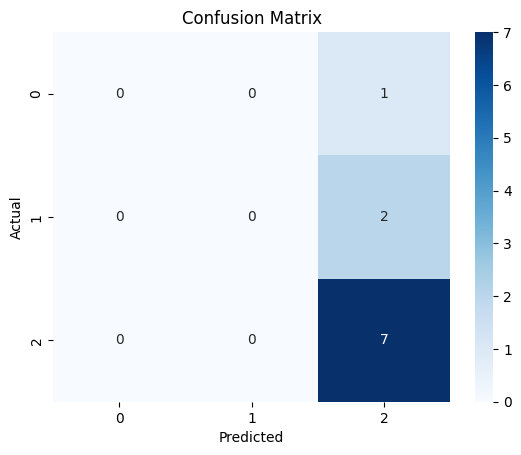

In [20]:
##Cell 18
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

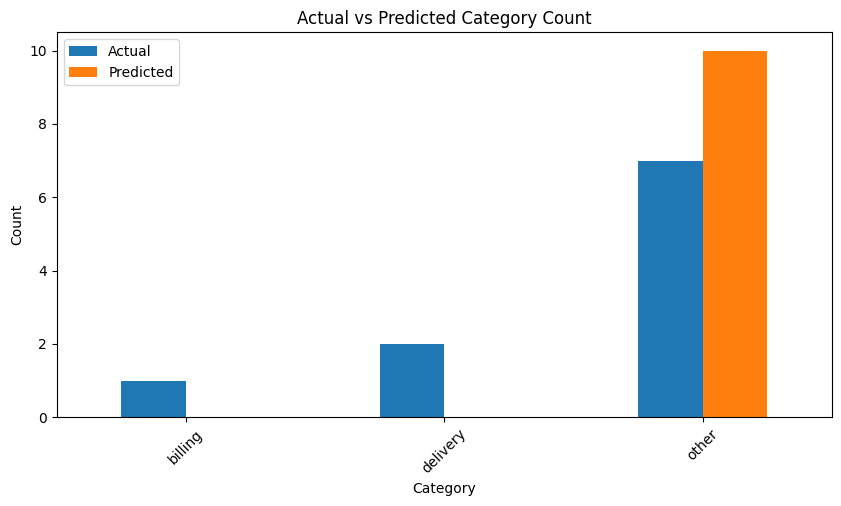

In [23]:
##Cell 19: Count Comparison (Actual vs Predicted)
import matplotlib.pyplot as plt

# Count values
actual_counts = pd.Series(y_test).value_counts()
pred_counts = pd.Series(y_pred).value_counts()

# Combine into one DataFrame
compare_df = pd.DataFrame({
    'Actual': actual_counts,
    'Predicted': pred_counts
}).fillna(0)

# Plot
compare_df.plot(kind='bar', figsize=(10,5))

plt.title("Actual vs Predicted Category Count")
plt.xlabel("Category")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()